In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier



from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import confusion_matrix
from sklearn.tree import export_graphviz
from sklearn.impute import SimpleImputer

import datetime
import xgboost as xgb


import numpy as np
import time
import datetime
import pydot
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt



# ĐỌC FILE CNTT_BATBUOC_DAXULY ở bước 1 tiền xử lý --> đưa vào dataframe tên là df
df = pd.read_csv('/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.1.TienXuLyDuLieu/lung_cancer_preprocessed.csv')

#in dữ liệu sau khi đọc từ file
print(df)

           AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0     0.682203       1        1                     1              1   
1     1.505110       1        1                     0              0   
2     0.049197       1        1                     0              0   
3    -0.837011       0        1                     0              1   
4     0.935405       0        1                     1              1   
...        ...     ...      ...                   ...            ...   
4995 -1.596618       0        1                     1              0   
4996  1.441810       0        1                     1              1   
4997 -0.393907       1        0                     0              1   
4998  1.188608       1        0                     1              0   
4999 -1.533317       0        1                     0              0   

      EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                         1                  0      0.

In [3]:
#kiem tra du lieu các cột còn thiếu giá trị (đếm các cột trống có dữ liệu trống)
df.isna().sum()

,0
AGE,0
GENDER,0
SMOKING,0
FINGER_DISCOLORATION,0
MENTAL_STRESS,0
EXPOSURE_TO_POLLUTION,0
LONG_TERM_ILLNESS,0
ENERGY_LEVEL,0
IMMUNE_WEAKNESS,0
BREATHING_ISSUE,0


CODE TÍNH AUC CHO 9 GIẢI THUẬT

In [4]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.7 MB/s eta 0:00:00


Columns: ['age', 'gender', 'smoking', 'finger_discoloration', 'mental_stress', 'exposure_to_pollution', 'long_term_illness', 'energy_level', 'immune_weakness', 'breathing_issue', 'alcohol_consumption', 'throat_discomfort', 'oxygen_saturation', 'chest_tightness', 'family_history', 'smoking_family_history', 'stress_immune', 'pulmonary_disease']


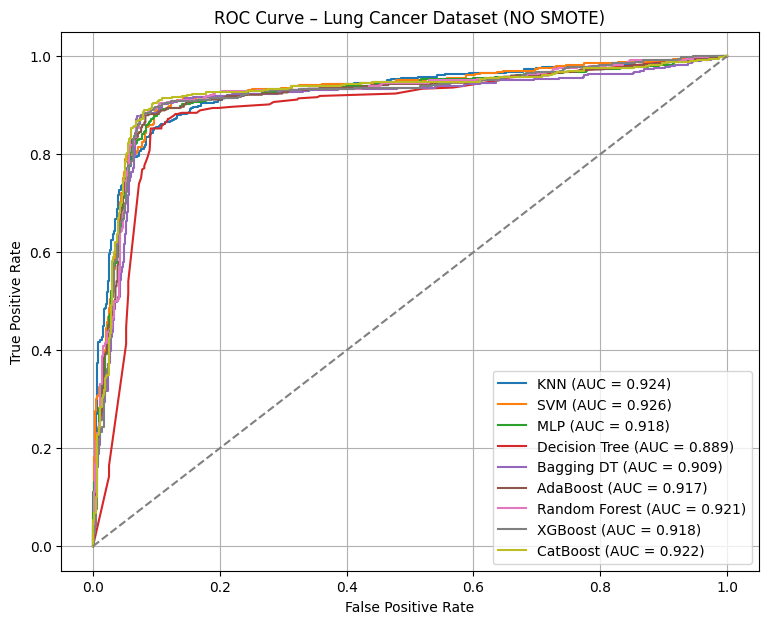


ROC–AUC SUMMARY
SVM            : 0.9261
KNN            : 0.9245
CatBoost       : 0.9223
Random Forest  : 0.9213
MLP            : 0.9180
XGBoost        : 0.9178
AdaBoost       : 0.9168
Bagging DT     : 0.9090
Decision Tree  : 0.8894

AUC results saved to auc_results_lung_cancer_no_smote.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    RandomForestClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# =========================
# 1️⃣ READ DATA
# =========================

# chuẩn hóa tên cột
df.columns = df.columns.str.strip().str.lower()
print("Columns:", df.columns.tolist())


# =========================
# 2️⃣ FEATURE / TARGET
# =========================
X = df.drop("pulmonary_disease", axis=1)
y = df["pulmonary_disease"]


# =========================
# 3️⃣ TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# =========================
# 4️⃣ HANDLE NaN (SAFE)
# =========================
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)


# =========================
# 5️⃣ DEFINE MODELS (AUC-ORIENTED)
# =========================
models = {

    "KNN": KNeighborsClassifier(
        n_neighbors=45,
        metric="manhattan",
        weights="distance"
    ),

    "SVM": SVC(
        kernel="rbf",
        C=20,
        gamma="auto",
        probability=True,
        class_weight="balanced"
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=500,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        criterion='entropy',
        random_state=42
    ),

    "Bagging DT": BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=8,
            class_weight="balanced",
            criterion='entropy'
        ),
        n_estimators=300,
        bootstrap=True,
        random_state=42,
        n_jobs=8
    ),

    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=8,
            class_weight="balanced",
            criterion='entropy'
        ),
        n_estimators=200,
        learning_rate=0.01,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=7,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric="logloss",
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=100,
        depth=7, # Added a default value for depth
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        verbose=0,
        random_seed=42
    )
}


# =========================
# 6️⃣ TRAIN – ROC – AUC
# =========================
plt.figure(figsize=(9, 7))
auc_results = {}

for name, model in models.items():

    model.fit(X_train_imp, y_train)

    y_prob = model.predict_proba(X_test_imp)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

    auc_results[name] = auc


# =========================
# 7️⃣ PLOT ROC
# =========================
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Lung Cancer Dataset (NO SMOTE)")
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.4.AUC/roc_curve_lung_cancer_no_smote.png', dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 8️⃣ AUC SUMMARY
# =========================
print("\nROC–AUC SUMMARY")
for k, v in sorted(auc_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{k:15s}: {v:.4f}")

auc_df = pd.DataFrame(
    sorted(auc_results.items(), key=lambda x: x[1], reverse=True),
    columns=["Model", "AUC"]
)

auc_df.to_csv('/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.4.AUC/auc_results_lung_cancer_no_smote.csv', index=False)
print("\nAUC results saved to auc_results_lung_cancer_no_smote.csv")